# E11 Final Project Data Analysis: Sr-90/Y-90 Beta Spectrum

This notebook follows the workflow below:

1. Import all CSV files of spectra.
2. Plot individual spectra and the background-subtracted average spectrum.  
3. Generate theoretical Sr-90, Y-90, and combined Sr-90/Y-90 spectra using the exact Fermi function, with no detector response.  
4. Fit a detector response function to the measured spectrum and compare the experimental, fitted, and no-detector theoretical spectra.


## 1. Import packages and CSV files of spectra

Each CSV file is interpreted as a time-resolved spectrum: the first column is timestamp and all remaining columns are energy bins. The function below skips the header row because the raw CSV header can contain fewer column names than the data rows.

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.special import gamma
from pathlib import Path


# file pathing #

cwd = Path.cwd()
spectrum0 = cwd.parent / 'datafolder' / 'spectrum.csv'
spectrum1 = cwd.parent / 'datafolder' / 'spectrum1.csv'
spectrum2 = cwd.parent / 'datafolder' / 'spectrum2.csv'
spectrum3 = cwd.parent / 'datafolder' / 'spectrum3.csv'
spectrum_bkg = cwd.parent / 'datafolder' / 'spectrum_bkg.csv'

# ------------------------------- #
    
# -----------------------------
# User inputs
# -----------------------------
bin_size_keV = 2.785      # determined from largest nonzero bin / max recorded energy
max_rows = 450            # use only first 900 s of data
Emax_plot = 3000          # plotting range, keV

# Fit region. This avoids letting near-zero high-energy bins dominate the normalization.
fit_min_keV = 20
fit_max_keV = 1200

# Source and background files.
# The resolver below handles spectrum1.csv vs spectrum1(2).csv automatically.
source_file_candidates = {
    "Spectrum 0": [spectrum0],
    "Spectrum 1": [spectrum1],
    "Spectrum 2": [spectrum2],
    "Spectrum 3": [spectrum3],
}
background_file_candidates = [spectrum_bkg]

# Sr-90 / Y-90 beta endpoints, keV
E0_Sr = 546.0
E0_Y = 2280.0

# Daughter nuclear charges for beta-minus decay
# Sr-90 -> Y-90: daughter Z = 39
# Y-90 -> Zr-90: daughter Z = 40
Z_Sr = 39
Z_Y = 40
A_mass = 90

# Physical constants
m_e_keV = 511.0
alpha = 1 / 137.036
hbar_c_keV_fm = 197326.9804

def resolve_file(candidates):
    """Return the first existing filename from a list of possible names"""
    for filename in candidates:
        if os.path.exists(filename):
            return filename
    raise FileNotFoundError(f"None of these files were found: {candidates}")

source_files = {label: resolve_file(candidates) for label, candidates in source_file_candidates.items()}
background_file = resolve_file(background_file_candidates)

print("Resolved input files:")
for label, filename in source_files.items():
    print(f"  {label}: {filename}")
print(f"  Background: {background_file}")


def load_spectrum(filepath, max_rows=None):
    """
    Load a time-resolved detector CSV

    Assumed structure after skipping first row:
    - column 0: timestamp
    - columns 1 onward: energy-bin counts

    Returns:
    - energy_keV: energy axis
    - counts: total counts in each bin summed over selected timestamps
    - df: loaded dataframe after row mask
    """
    df = pd.read_csv(filepath, header=None, skiprows=1)

    if max_rows is not None:
        df = df.iloc[:max_rows]

    counts = df.iloc[:, 1:].sum(axis=0).to_numpy(dtype=float)
    energy_keV = np.arange(len(counts)) * bin_size_keV

    return energy_keV, counts, df

# Load all source spectra
all_spectra = {}
energy_keV = None

for label, filepath in source_files.items():
    energy_keV, counts, _ = load_spectrum(filepath, max_rows=max_rows)
    all_spectra[label] = counts

# Load background spectrum
energy_keV_bkg, background_counts, _ = load_spectrum(background_file, max_rows=max_rows)

# Trim to the shorter length if they differ
min_len = min(len(energy_keV), len(background_counts))
energy_keV = energy_keV[:min_len]
background_counts = background_counts[:min_len]
for label in all_spectra:
    all_spectra[label] = all_spectra[label][:min_len]

print(f"\nLoaded {len(all_spectra)} source spectra, {len(energy_keV)} energy bins each.")

Resolved input files:
  Spectrum 0: c:\Users\dogem\OneDrive\Desktop\Project Folder\E11aga\datafolder\spectrum.csv
  Spectrum 1: c:\Users\dogem\OneDrive\Desktop\Project Folder\E11aga\datafolder\spectrum1.csv
  Spectrum 2: c:\Users\dogem\OneDrive\Desktop\Project Folder\E11aga\datafolder\spectrum2.csv
  Spectrum 3: c:\Users\dogem\OneDrive\Desktop\Project Folder\E11aga\datafolder\spectrum3.csv
  Background: c:\Users\dogem\OneDrive\Desktop\Project Folder\E11aga\datafolder\spectrum_bkg.csv

Loaded 4 source spectra, 4095 energy bins each.


## 2. Plot individual energy spectra and the background-subtracted average spectrum

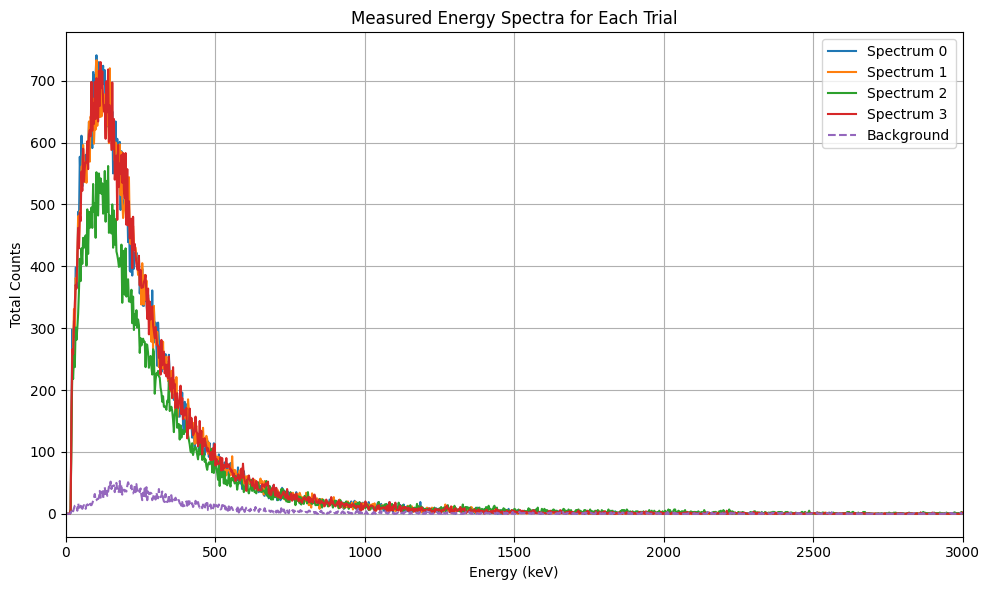

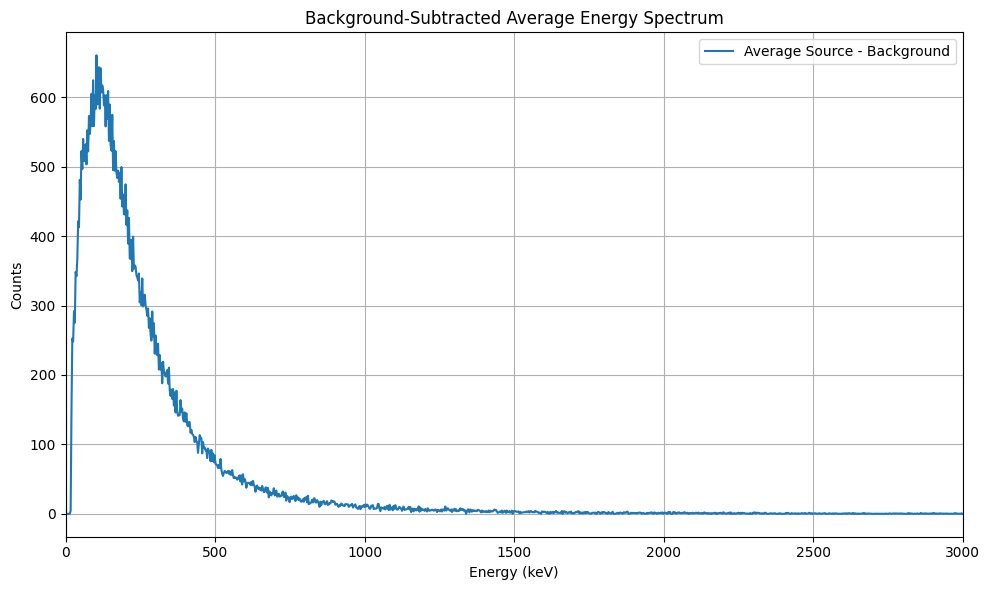

In [7]:
# Build source array and average source spectrum
source_labels = list(source_files.keys())
source_array = np.array([all_spectra[label] for label in source_labels])
avg_source_counts = np.mean(source_array, axis=0)

# Background-subtracted average spectrum
exp_counts_full = avg_source_counts - background_counts
exp_counts_full = np.clip(exp_counts_full, 0, None)

# Restrict plotting/analysis energy range
plot_mask = energy_keV <= Emax_plot
E = energy_keV[plot_mask]
exp_counts = exp_counts_full[plot_mask]
background_counts_plot = background_counts[plot_mask]

# Individual spectra
plt.figure(figsize=(10, 6))
for label in source_labels:
    plt.plot(E, all_spectra[label][plot_mask], label=label)
plt.plot(E, background_counts_plot, linestyle="--", label="Background")

plt.xlabel("Energy (keV)")
plt.ylabel("Total Counts")
plt.title("Measured Energy Spectra for Each Trial")
plt.xlim(0, Emax_plot)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Background-subtracted average spectrum
plt.figure(figsize=(10, 6))
plt.plot(E, exp_counts, label="Average Source - Background")

plt.xlabel("Energy (keV)")
plt.ylabel("Counts")
plt.title("Background-Subtracted Average Energy Spectrum")
plt.xlim(0, Emax_plot)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. Theoretical Sr-90 and Y-90 spectra using the exact Fermi function

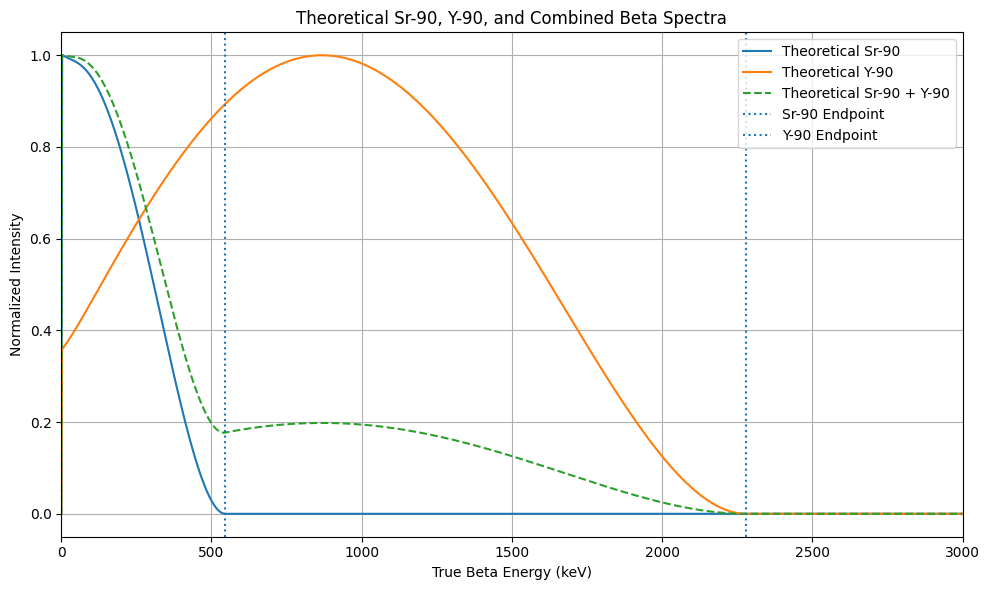

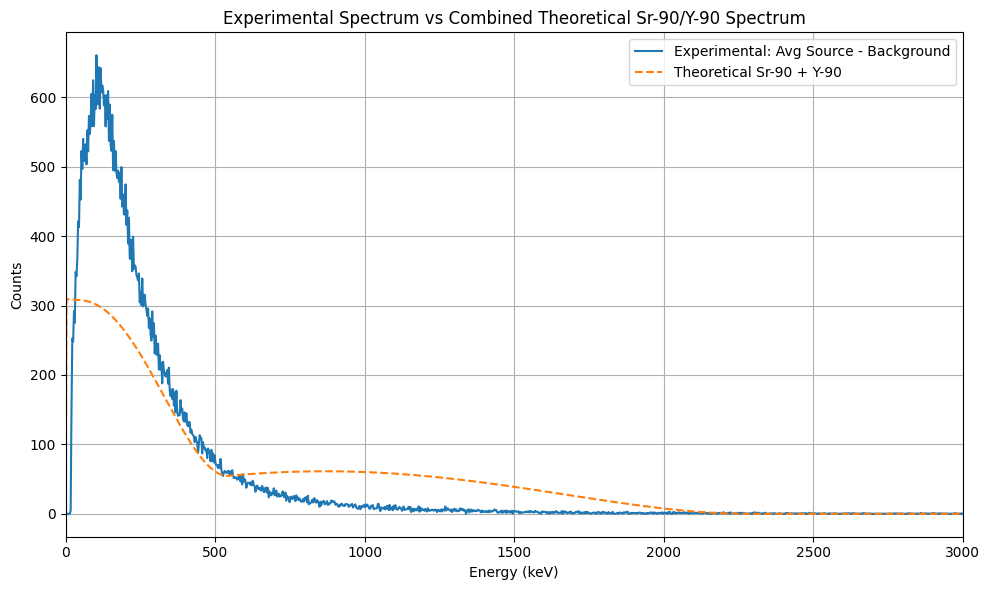

In [8]:
def electron_momentum(E_keV):
    """Relativistic electron momentum in keV/c using kinetic energy"""
    return np.sqrt(E_keV**2 + 2 * E_keV * m_e_keV)


def nuclear_radius_fm(A):
    """Approximate nuclear radius R = r0 A^(1/3), with r0 ≈ 1.2 fm"""
    return 1.2 * A**(1/3)


def fermi_function_exact(Z, A, E_keV):
    """
    Relativistic finite-size Fermi function for beta-minus decay

    F(Z,E) = [2(1+S)/Gamma(1+2S)^2] (2 p R / hbar)^([2S - 2]) exp(pi eta) |Gamma(S + i eta)|^2
    """
    E_total = E_keV + m_e_keV
    p = electron_momentum(E_keV)

    F = np.ones_like(E_keV)
    valid = p > 0

    R_fm = nuclear_radius_fm(A)
    S = np.sqrt(1 - (alpha * Z)**2)

    eta = np.zeros_like(E_keV)
    eta[valid] = alpha * Z * E_total[valid] / p[valid]

    rho = p[valid] * R_fm / hbar_c_keV_fm

    prefactor = 2 * (1 + S) / (gamma(1 + 2 * S)**2)
    power_term = (2 * rho)**(2 * S - 2)
    exp_term = np.exp(np.pi * eta[valid])
    gamma_term = np.abs(gamma(S + 1j * eta[valid]))**2

    F[valid] = prefactor * power_term * exp_term * gamma_term

    return F


def beta_spectrum_exact(E_keV, E0_keV, Z, A=90):
    """
    Allowed beta spectrum using the exact Fermi function.
    The spectrum is normalized to unit area.
    """
    N = np.zeros_like(E_keV)
    valid = (E_keV > 0) & (E_keV < E0_keV)

    Ev = E_keV[valid]
    p = electron_momentum(Ev)
    E_total = Ev + m_e_keV
    F = fermi_function_exact(Z, A, Ev)

    N[valid] = F * p * E_total * (E0_keV - Ev)**2

    area = np.trapezoid(N, E_keV)
    if area > 0:
        N /= area

    return N

# Theoretical spectra with no detector response
N_Sr_true = beta_spectrum_exact(E, E0_Sr, Z_Sr, A=A_mass)
N_Y_true = beta_spectrum_exact(E, E0_Y, Z_Y, A=A_mass)

# Secular equilibrium: equal activities
N_combined_true = N_Sr_true + N_Y_true

plt.figure(figsize=(10, 6))
plt.plot(E, N_Sr_true / N_Sr_true.max(), label="Theoretical Sr-90")
plt.plot(E, N_Y_true / N_Y_true.max(), label="Theoretical Y-90")
plt.plot(E, N_combined_true / N_combined_true.max(), linestyle="--", label="Theoretical Sr-90 + Y-90")

plt.axvline(E0_Sr, linestyle=":", label="Sr-90 Endpoint")
plt.axvline(E0_Y, linestyle=":", label="Y-90 Endpoint")

plt.xlabel("True Beta Energy (keV)")
plt.ylabel("Normalized Intensity")
plt.title("Theoretical Sr-90, Y-90, and Combined Beta Spectra")
plt.xlim(0, Emax_plot)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ======================================================================================================================
# Plot background-subtracted average spectrum with combined theoretical Sr-90 + Y-90 spectrum without detector response
# ======================================================================================================================

# Combined theoretical spectrum, equal activities from secular equilibrium
N_combined_true = N_Sr_true + N_Y_true

# Scale theoretical spectrum to experimental spectrum
true_scale = np.sum(exp_counts) / np.sum(N_combined_true)
true_counts = true_scale * N_combined_true

plt.figure(figsize=(10, 6))

plt.plot(E, exp_counts, label="Experimental: Avg Source - Background")
plt.plot(E, true_counts, linestyle="--", label="Theoretical Sr-90 + Y-90")

plt.xlabel("Energy (keV)")
plt.ylabel("Counts")
plt.title("Experimental Spectrum vs Combined Theoretical Sr-90/Y-90 Spectrum")
plt.xlim(0, 3000)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 5. Fit detector response function and compare experimental spectrum to fitted model

The detector response is modeled as a forward response: with an energy-dependent mixture of a Gaussian full-energy response and a low-energy tail. The fit is performed only in the selected fit region to avoid allowing many nearly-zero high-energy bins to dominate the normalization.

The maximum number of function evaluations is exceeded.
Function evaluations 200, initial cost 5.8010e+03, final cost 5.1761e+02, first-order optimality 3.02e+01.

Fitted detector-response parameters:
sigma0       = 86.55 keV
sigma_frac   = 0.2458
f0           = 1.362e-34
f1           = 2
lambda0      = 1.992 keV
lambda1      = 0.1991
Ec           = 513.6 keV
n_eff        = 2.907
scale        = 1.472e+05

Chi-squared          = 1035
Degrees of freedom   = 415
Reduced chi-squared  = 2.494


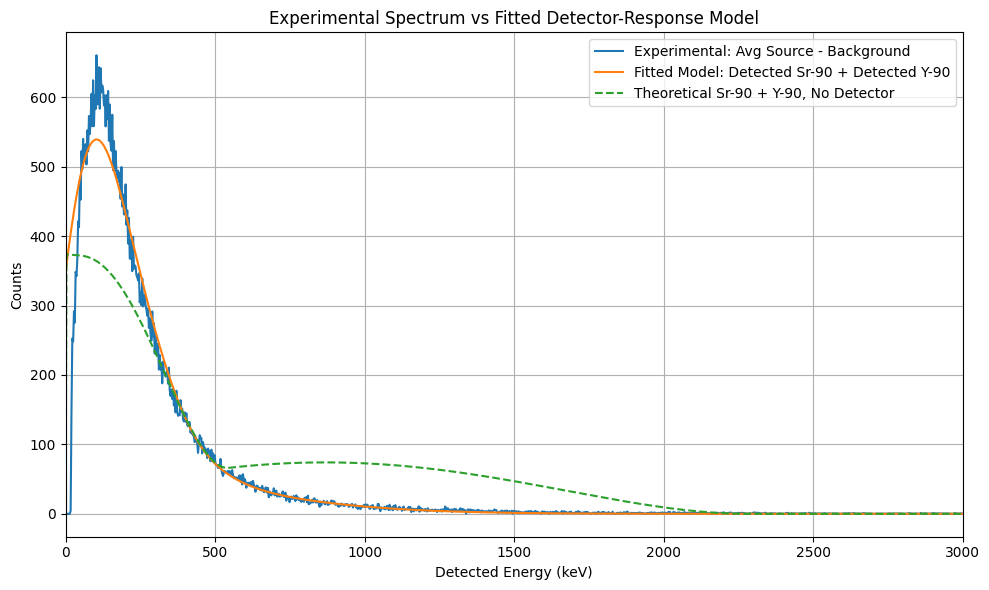

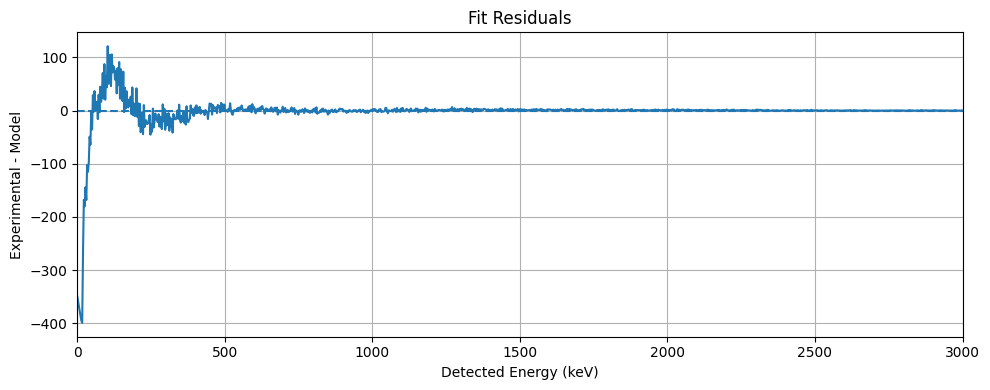

In [9]:
fit_mask = (E >= fit_min_keV) & (E <= fit_max_keV)


def apply_detector_response(E, N_true, sigma0, sigma_frac, f0, f1, lambda0, lambda1, Ec, n_eff, Emax_ref=2280.0):
    """
    Semi-empirical beta detector response.

    sigma(E') = sqrt(sigma0^2 + (sigma_frac E')^2)
    f_tail(E') = f0 + f1 E'/Emax_ref
    lambda(E') = lambda0 + lambda1 E'
    eps(E') = 1 / [1 + (E'/Ec)^n_eff]

    The low-energy tail only allows E_detected <= E_true.
    """
    N_det = np.zeros_like(N_true)

    for k, E_true in enumerate(E):
        if N_true[k] <= 0:
            continue

        sigma = np.sqrt(sigma0**2 + (sigma_frac * E_true)**2)

        f_tail = f0 + f1 * (E_true / Emax_ref)
        f_tail = np.clip(f_tail, 0.0, 0.98)

        tail_scale = lambda0 + lambda1 * E_true
        tail_scale = max(tail_scale, 1.0)

        efficiency = 1.0 / (1.0 + (E_true / Ec)**n_eff)

        # Gaussian full-energy response
        gaussian = np.exp(-0.5 * ((E - E_true) / sigma)**2)
        if gaussian.sum() > 0:
            gaussian /= gaussian.sum()

        # Low-energy loss tail, no upward energy shifts allowed
        tail = np.zeros_like(E)
        lower = E <= E_true
        tail[lower] = np.exp(-(E_true - E[lower]) / tail_scale)
        if tail.sum() > 0:
            tail /= tail.sum()

        response = (1 - f_tail) * gaussian + f_tail * tail
        if response.sum() > 0:
            response /= response.sum()

        # Do not renormalize after efficiency, efficiency should reduce counts
        N_det += efficiency * N_true[k] * response

    return N_det


def build_model(params):
    """
    params = [sigma0, sigma_frac, f0, f1, lambda0, lambda1, Ec, n_eff]
    """
    sigma0, sigma_frac, f0, f1, lambda0, lambda1, Ec, n_eff = params

    N_Sr_det = apply_detector_response(E, N_Sr_true, sigma0, sigma_frac, f0, f1, lambda0, lambda1, Ec, n_eff, Emax_ref=E0_Y)

    N_Y_det = apply_detector_response(E, N_Y_true, sigma0, sigma_frac, f0, f1, lambda0, lambda1, Ec, n_eff, Emax_ref=E0_Y)

    # Equal Sr-90 and Y-90 activities due to secular equilibrium
    model_shape = N_Sr_det + N_Y_det

    # Normalize only over fit region
    data_fit = exp_counts[fit_mask]
    model_fit = model_shape[fit_mask]

    denominator = np.sum(model_fit)
    if denominator > 0:
        scale = np.sum(data_fit) / denominator
    else:
        scale = 1.0

    model_counts = scale * model_shape

    return model_counts, scale, N_Sr_det, N_Y_det


def residuals(params):
    model_counts, _, _, _ = build_model(params)

    data_fit = exp_counts[fit_mask]
    model_fit = model_counts[fit_mask]

    # Poisson-like uncertainty estimate
    uncertainty = np.sqrt(data_fit + 1.0)

    return (model_fit - data_fit) / uncertainty

# Initial guesses
p0 = np.array([
    20.0,    # sigma0, keV
    0.05,    # sigma_frac
    0.20,    # f0
    0.70,    # f1
    50.0,    # lambda0, keV
    0.30,    # lambda1
    900.0,   # Ec, keV
    2.0      # n_eff
])

# Parameter bounds
lower_bounds = np.array([
    1.0,      # sigma0
    0.0,      # sigma_frac
    0.0,      # f0
    0.0,      # f1
    1.0,      # lambda0
    0.0,      # lambda1
    100.0,    # Ec
    0.5       # n_eff
])

upper_bounds = np.array([
    200.0,    # sigma0
    0.50,     # sigma_frac
    0.95,     # f0
    2.0,      # f1
    1000.0,   # lambda0
    2.0,      # lambda1
    5000.0,   # Ec
    8.0       # n_eff
])

fit_result = least_squares(residuals, p0, bounds=(lower_bounds, upper_bounds), max_nfev=200, verbose=1)

popt = fit_result.x
model_counts, scale_fit, N_Sr_det_fit, N_Y_det_fit = build_model(popt)

sigma0_fit, sigma_frac_fit, f0_fit, f1_fit, lambda0_fit, lambda1_fit, Ec_fit, n_eff_fit = popt

print("\nFitted detector-response parameters:")
print(f"sigma0       = {sigma0_fit:.4g} keV")
print(f"sigma_frac   = {sigma_frac_fit:.4g}")
print(f"f0           = {f0_fit:.4g}")
print(f"f1           = {f1_fit:.4g}")
print(f"lambda0      = {lambda0_fit:.4g} keV")
print(f"lambda1      = {lambda1_fit:.4g}")
print(f"Ec           = {Ec_fit:.4g} keV")
print(f"n_eff        = {n_eff_fit:.4g}")
print(f"scale        = {scale_fit:.4g}")

weighted_resid = residuals(popt)
chi2 = np.sum(weighted_resid**2)
dof = np.sum(fit_mask) - len(popt)
reduced_chi2 = chi2 / dof

print(f"\nChi-squared          = {chi2:.4g}")
print(f"Degrees of freedom   = {dof}")
print(f"Reduced chi-squared  = {reduced_chi2:.4g}")

# Scaled components
Sr_model_counts = scale_fit * N_Sr_det_fit
Y_model_counts = scale_fit * N_Y_det_fit

# Scale no-detector theoretical spectrum over the fit region for comparison
true_scale = np.sum(exp_counts[fit_mask]) / np.sum(N_combined_true[fit_mask])
true_counts = true_scale * N_combined_true

# Plot: experimental, fitted detector model, and no-detector theory
plt.figure(figsize=(10, 6))

plt.plot(E, exp_counts, label="Experimental: Avg Source - Background")
plt.plot(E, model_counts, label="Fitted Model: Detected Sr-90 + Detected Y-90")
plt.plot(E, true_counts, linestyle="--", label="Theoretical Sr-90 + Y-90, No Detector")

plt.xlabel("Detected Energy (keV)")
plt.ylabel("Counts")
plt.title("Experimental Spectrum vs Fitted Detector-Response Model")
plt.xlim(0, Emax_plot)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot residuals
plt.figure(figsize=(10, 4))
resid = exp_counts - model_counts
plt.plot(E, resid)
plt.axhline(0, linestyle="--")
plt.xlabel("Detected Energy (keV)")
plt.ylabel("Experimental - Model")
plt.title("Fit Residuals")
plt.xlim(0, Emax_plot)
plt.grid(True)
plt.tight_layout()
plt.show()